In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, ttest_ind

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')

In [2]:
df=pd.read_csv('features.csv')
df['avg_days_to_repay'] = df['avg_days_to_repay'].fillna(df['avg_days_to_repay'].median())
df['avg_monthly_repayment'] = df['avg_monthly_repayment'].fillna(df['avg_monthly_repayment'].mean())


print(df.head())
df.head()
df.info()
df.describe()


   merchant_id  num_drawdowns  repay_within_1d  repay_within_5d  \
0    100274288              5                1                0   
1    100278695              2                1                0   
2    107648451             22                8                1   
3    109767281              1                1                0   
4    109849158             38               20                0   

   repay_after_5d  avg_monthly_drawdown  avg_monthly_repayment  \
0               2         117000.000000           18952.076667   
1               0          16000.000000            8003.500000   
2               0         510900.000000          308288.100000   
3               0          10000.000000           11144.600000   
4               1          43785.363636           40303.251667   

   avg_monthly_pending_balance  total_drawdown_ttm  total_repayment_ttm  \
0                 83270.517556             34000.0            170558.35   
1                  3196.650000                 0.0

,merchant_id,num_drawdowns,repay_within_1d,repay_within_5d,repay_after_5d,avg_monthly_drawdown,avg_monthly_repayment,avg_monthly_pending_balance,total_drawdown_ttm,total_repayment_ttm,successful_apps,repayment_ratio_ttm,avg_days_to_repay
count,3.570000e+02,357.000000,357.000000,357.000000,357.000000,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,357.000000,357.000000,357.000000
mean,4.417902e+09,52.521008,30.196078,2.591036,2.649860,7.041938e+04,4.984993e+04,1.237891e+05,5.873664e+05,5.016698e+05,1.030812,0.762101,22.919277
std,2.309748e+10,73.206363,44.797242,3.763474,2.457065,1.433877e+05,1.077741e+05,1.078236e+06,1.905954e+06,1.686876e+06,0.337959,2.750638,31.022935
min,1.002743e+08,1.000000,0.000000,0.000000,0.000000,1.000000e+02,1.823200e+02,-5.549889e+04,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,1.255896e+08,5.000000,2.000000,0.000000,1.000000,8.933333e+03,6.381377e+03,2.000000e+03,0.000000e+00,0.000000e+00,1.000000,0.000000,7.844238
50%,1.328489e+08,22.000000,10.000000,1.000000,2.000000,2.172500e+04,1.600000e+04,5.355738e+03,8.800000e+03,1.204482e+04,1.000000,0.670402,15.571789
75%,1.466493e+08,66.000000,37.000000,4.000000,4.000000,6.475567e+04,4.984993e+04,2.593514e+04,2.575940e+05,2.196729e+05,1.000000,0.996467,25.557397
max,1.487310e+11,490.000000,240.000000,25.000000,11.000000,1.214696e+06,1.099608e+06,1.700547e+07,2.006800e+07,1.851453e+07,4.000000,46.727931,282.254283


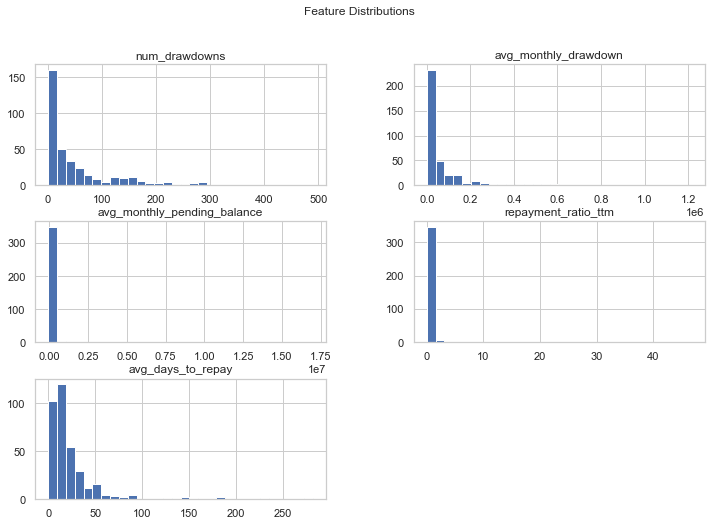

In [3]:
cols = [
    'num_drawdowns',
    'avg_monthly_drawdown',
    'avg_monthly_pending_balance',
    'repayment_ratio_ttm',
    'avg_days_to_repay'
]

df[cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

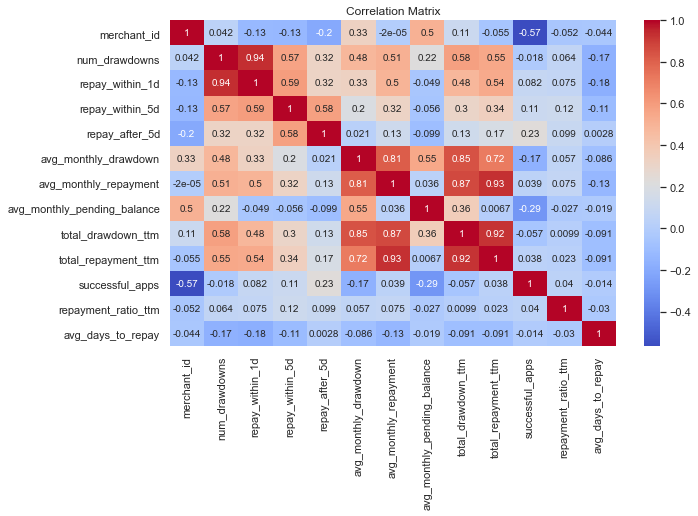

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

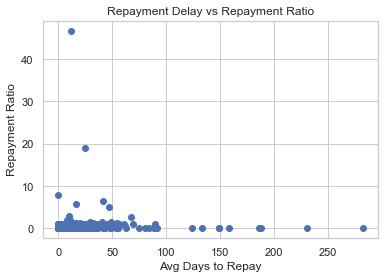

In [5]:
plt.scatter(df['avg_days_to_repay'], df['repayment_ratio_ttm'])
plt.xlabel("Avg Days to Repay")
plt.ylabel("Repayment Ratio")
plt.title("Repayment Delay vs Repayment Ratio")
plt.show()

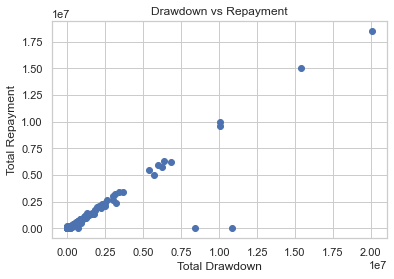

In [6]:
plt.scatter(df['total_drawdown_ttm'], df['total_repayment_ttm'])
plt.xlabel("Total Drawdown")
plt.ylabel("Total Repayment")
plt.title("Drawdown vs Repayment")
plt.show()

In [7]:
corr, p = pearsonr(df['repay_within_1d'], df['repayment_ratio_ttm'])
print("Correlation:", corr, "P-value:", p)

Correlation: 0.07520278391504001 P-value: 0.15620825442483854


In [8]:
corr, p = pearsonr(df['repay_after_5d'], df['repayment_ratio_ttm'])
print("Correlation:", corr, "P-value:", p)

Correlation: 0.09857439453672648 P-value: 0.06281341027238681


In [9]:
corr, p = pearsonr(df['avg_monthly_pending_balance'], df['avg_days_to_repay'])
print("Correlation:", corr, "P-value:", p)

Correlation: -0.0188970688748215 P-value: 0.721968489828489


In [11]:
X=df.drop('merchant_id',axis=1)

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\

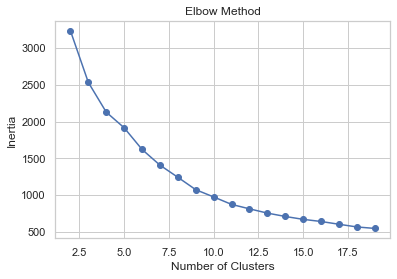

In [14]:
inertia = []

for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,20), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [16]:
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=2, Silhouette Score=0.7036382187790531
K=3, Silhouette Score=0.4109006870781768
K=4, Silhouette Score=0.41943011357918714


c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=5, Silhouette Score=0.4290806128257822
K=6, Silhouette Score=0.428822784315666
K=7, Silhouette Score=0.3840840612730919


c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=8, Silhouette Score=0.3335702466887937
K=9, Silhouette Score=0.34643061671869607


c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

c:\users\rishi\appdata\local\programs\python\python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [19]:
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)

          merchant_id  num_drawdowns  repay_within_1d  repay_within_5d  \
cluster                                                                  
0        1.355879e+08       7.882353         3.117647         0.529412   
1        5.328550e+09      18.706122        10.073469         0.987755   
2        1.309293e+08     228.222222       137.666667         8.888889   
3        1.320341e+08     136.726190        83.571429         7.071429   
4        1.285610e+11     247.000000         0.000000         0.000000   

         repay_after_5d  avg_monthly_drawdown  avg_monthly_repayment  \
cluster                                                                
0              1.352941          39451.916807           14807.027881   
1              1.836735          40088.194508           24226.803705   
2              3.777778         613072.789290          576713.953704   
3              5.226190          85390.666764           75226.347765   
4              0.000000         978478.687500    

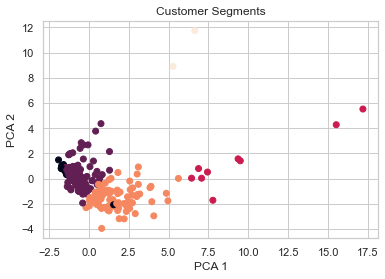

In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments")
plt.show()

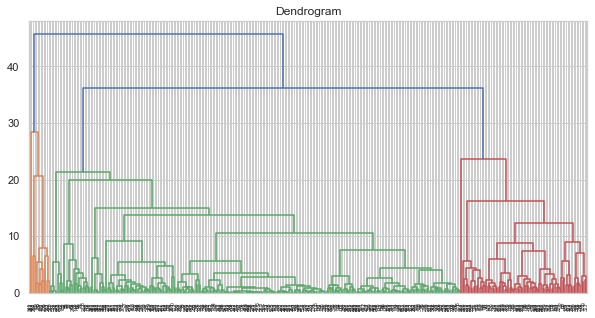

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [23]:
from scipy.cluster.hierarchy import fcluster

df['hc_cluster'] = fcluster(linked, t=3, criterion='maxclust')

In [24]:
from sklearn.metrics import silhouette_score

print("KMeans:", silhouette_score(X_scaled, df['cluster']))
print("Hierarchical:", silhouette_score(X_scaled, df['hc_cluster']))

KMeans: 0.4290806128257822
Hierarchical: 0.40688010307278655
